<a href="https://colab.research.google.com/github/AnastasiaDolotova/investment-client-analysis/blob/main/investment_client_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd
import plotly.express as px
import numpy as np
from scipy.stats import f_oneway
from scipy.stats import spearmanr, kendalltau
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

#Загрузка и подготовка данных

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !sudo apt-get install unrar

In [ ]:
# !mkdir /content/drive/MyDrive/unpacked_data
# !unrar x "/content/drive/MyDrive/invest_db.rar" /content/drive/MyDrive/unpacked_data

In [ ]:
csv_path = "/content/drive/MyDrive/unpacked_data/invest_db.csv"
df = pd.read_csv(csv_path, sep=';')

In [ ]:
df.columns

Index(['id', 'date', 'age', 'education_level_cd', 'marital_status_cd',
       'children_cnt', 'monthly_income_amt', 'invest_utilization_dt',
       'forts_flg', 'margin_status_flg', 'qualified_investor_flg',
       'in_payment_rub_amt', 'out_payment_rub_amt', 'uncovered_position_amt',
       'turnover_rus_bon_amt', 'turnover_rus_sec_amt', 'turnover_forts_amt',
       'turnover_cur_amt', 'turnover_etf_amt', 'turnover_fnd_amt',
       'turnover_opt_amt', 'turnover_ore_prc_amt', 'turnover_ore_sel_amt',
       'turnover_tracking_amt', 'trade_order_rus_sec_cnt',
       'trade_order_rus_bon_cnt', 'trade_order_forts_cnt',
       'trade_order_cur_cnt', 'trade_order_etf_cnt', 'trade_order_fnd_cnt',
       'trade_order_opt_cnt', 'trade_order_ore_prc_cnt',
       'trade_order_ore_sel_cnt', 'trade_order_tracking_cnt',
       'portf_total_amt', 'portf_mex_amt', 'portf_rus_sec_amt',
       'portf_rus_bon_amt', 'initial_margin_amt', 'portf_cur_amt',
       'portf_etf_amt', 'portf_fnd_amt', 'portf_opt

In [ ]:
df.head()

,id,date,age,education_level_cd,marital_status_cd,children_cnt,monthly_income_amt,invest_utilization_dt,forts_flg,margin_status_flg,...,portf_fnd_amt,portf_opt_amt,portf_ore_amt,ccr_balance_amt,cor_balance_amt,lon_balance_amt,posts,comments,reacts,reads
0,1479787897,2024-04-20,33,NaN,UNM,"0,0","31272,0",2023-09-13,1,0,...,"428,0","0,0","0,0","-11298,0","541,0","0,0","0,0","0,0","0,0","0,0"
1,601760063,2024-02-01,29,GRD,UNM,"0,0","6284,0",2021-03-29,0,0,...,"23,0","0,0","0,0",NaN,"8115,0","0,0","0,0","0,0","0,0","0,0"
2,61175329,2024-02-10,38,SCH,MAR,"0,0","1904,0",2023-12-05,1,0,...,"193,0","0,0","0,0","0,0","25,0",NaN,"0,0","0,0","0,0","2,0"
3,1411700618,2024-03-05,64,NaN,NaN,"0,0",NaN,2021-09-16,0,0,...,"0,0","0,0","0,0",NaN,"65,0",NaN,"0,0","0,0","0,0","0,0"
4,2096755145,2024-02-10,31,NaN,UNM,"0,0",NaN,2022-03-01,0,0,...,"0,0","0,0","0,0","0,0","0,0",NaN,"0,0","0,0","0,0","0,0"


In [ ]:
df.sample(5)

,id,date,age,education_level_cd,marital_status_cd,children_cnt,monthly_income_amt,invest_utilization_dt,forts_flg,margin_status_flg,...,portf_fnd_amt,portf_opt_amt,portf_ore_amt,ccr_balance_amt,cor_balance_amt,lon_balance_amt,posts,comments,reacts,reads
334534,1217991394,2024-02-23,54,GRD,UNM,"0,0","6283,0",2021-04-27,0,0,...,"0,0","0,0","0,0","0,0","14,0",NaN,"0,0","0,0","0,0","0,0"
307534,1756274117,2024-04-18,57,UGR,MAR,"0,0","4709,0",2019-11-19,0,0,...,"1255,0","0,0","0,0","0,0","5955,0","33,0","0,0","0,0","0,0","0,0"
232533,142336875,2024-02-18,41,NaN,NaN,"0,0","4714,0",2020-03-31,1,1,...,"0,0","0,0","0,0",NaN,"10795,0","-46485,0","0,0","0,0","0,0","0,0"
191662,1386380669,2024-04-14,50,NaN,NaN,"0,0","2212,0",2022-12-06,0,0,...,"0,0","0,0","0,0","0,0","257,0",NaN,"0,0","0,0","0,0","0,0"
374810,1593473578,2024-04-18,42,SCH,CIV,"0,0","2213,0",2023-12-18,0,0,...,"70,0","0,0","0,0","0,0","22,0","0,0",NaN,NaN,NaN,NaN


In [ ]:
df.shape

(458370, 51)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458370 entries, 0 to 458369
Data columns (total 51 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   id                        458370 non-null  int64 
 1   date                      458370 non-null  object
 2   age                       458370 non-null  int64 
 3   education_level_cd        233460 non-null  object
 4   marital_status_cd         267030 non-null  object
 5   children_cnt              410310 non-null  object
 6   monthly_income_amt        355140 non-null  object
 7   invest_utilization_dt     458370 non-null  object
 8   forts_flg                 458370 non-null  int64 
 9   margin_status_flg         458370 non-null  int64 
 10  qualified_investor_flg    458370 non-null  int64 
 11  in_payment_rub_amt        458370 non-null  object
 12  out_payment_rub_amt       458370 non-null  object
 13  uncovered_position_amt    458370 non-null  object
 14  turn

Приведем значения некоторых столбцов (children_cnt, monthly_income_amt и т.п.) к числовому виду

In [ ]:
cols_to_convert = [col for col in df.columns if col.endswith(('_amt', '_cnt'))]
cols_to_convert.extend(['posts', 'comments', 'reacts', 'reads'])

df[cols_to_convert] = (
    df[cols_to_convert]
    .replace(',', '.', regex=True)
    .apply(pd.to_numeric, errors='coerce')
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458370 entries, 0 to 458369
Data columns (total 51 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        458370 non-null  int64  
 1   date                      458370 non-null  object 
 2   age                       458370 non-null  int64  
 3   education_level_cd        233460 non-null  object 
 4   marital_status_cd         267030 non-null  object 
 5   children_cnt              410310 non-null  float64
 6   monthly_income_amt        355140 non-null  float64
 7   invest_utilization_dt     458370 non-null  object 
 8   forts_flg                 458370 non-null  int64  
 9   margin_status_flg         458370 non-null  int64  
 10  qualified_investor_flg    458370 non-null  int64  
 11  in_payment_rub_amt        458370 non-null  float64
 12  out_payment_rub_amt       458370 non-null  float64
 13  uncovered_position_amt    458370 non-null  f

In [ ]:
df.head()

,id,date,age,education_level_cd,marital_status_cd,children_cnt,monthly_income_amt,invest_utilization_dt,forts_flg,margin_status_flg,...,portf_fnd_amt,portf_opt_amt,portf_ore_amt,ccr_balance_amt,cor_balance_amt,lon_balance_amt,posts,comments,reacts,reads
0,1479787897,2024-04-20,33,NaN,UNM,0.0,31272.0,2023-09-13,1,0,...,428.0,0.0,0.0,-11298.0,541.0,0.0,0.0,0.0,0.0,0.0
1,601760063,2024-02-01,29,GRD,UNM,0.0,6284.0,2021-03-29,0,0,...,23.0,0.0,0.0,NaN,8115.0,0.0,0.0,0.0,0.0,0.0
2,61175329,2024-02-10,38,SCH,MAR,0.0,1904.0,2023-12-05,1,0,...,193.0,0.0,0.0,0.0,25.0,NaN,0.0,0.0,0.0,2.0
3,1411700618,2024-03-05,64,NaN,NaN,0.0,NaN,2021-09-16,0,0,...,0.0,0.0,0.0,NaN,65.0,NaN,0.0,0.0,0.0,0.0
4,2096755145,2024-02-10,31,NaN,UNM,0.0,NaN,2022-03-01,0,0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0


# Пропуски в данных

Посмотрим, есть ли пропуски в данных и, если есть, то в каких столбцах

In [ ]:
df.isna().any()[df.isna().any()]

,0
education_level_cd,True
marital_status_cd,True
children_cnt,True
monthly_income_amt,True
ccr_balance_amt,True
cor_balance_amt,True
lon_balance_amt,True
posts,True
comments,True
reacts,True


Пропуски имеются, посчитаем соотношение между ними и общим количеством данных

In [ ]:
df.isna().sum().sum() / df.size

np.float64(0.04802939828984804)

Число пропусков составляет примерно 4.8% от общего количества имеющихся данных.

Посмотрим на соотношение между пропусками и общим числом данных для всех столбцов, в которых имеются пропуски:

In [ ]:
df.isna().mean()[df.isna().any()]

,0
education_level_cd,0.490673
marital_status_cd,0.417436
children_cnt,0.104850
monthly_income_amt,0.225211
ccr_balance_amt,0.364396
cor_balance_amt,0.002317
lon_balance_amt,0.676019
posts,0.042149
comments,0.042149
reacts,0.042149


#Анализ распределения значений в признаках

In [ ]:
def draw_hist(name, title, xaxis_title, yaxis_title, df):
    fig = px.histogram(df, x=name, title=title, color_discrete_sequence=['#FCB2CE'])
    fig.update_layout(xaxis_title=xaxis_title, yaxis_title=yaxis_title)
    fig.update_traces(marker_line_width=1, marker_line_color="white")
    fig.show()

def draw_pie(name, title, df):
    fig = px.pie(df, values=np.ones(len(df)), names=name,
    title=title, color=name,
    color_discrete_sequence=px.colors.sequential.matter)
    fig.show()

def draw_box(df, data, title, labels, yaxis_title):
    fig = px.box(
        df,
        y=data,
        color_discrete_sequence=['hotpink'],
        title=title,
        labels=labels,
        points='all'
    )
    fig.update_layout(yaxis_title=yaxis_title)
    fig.show()

##Возраст

In [ ]:
unique_ages = df.groupby('id')['age'].first().reset_index()

In [ ]:
unique_ages.age.describe()

,age
count,5093.000000
mean,40.533674
std,10.918604
min,18.000000
25%,33.000000
50%,40.000000
75%,47.000000
max,86.000000


In [ ]:
unique_ages.age.value_counts()

,count
age,
40,217
36,216
38,212
39,207
37,204
...,...
86,1
82,1
79,1


In [ ]:
draw_hist('age', 'Распределение возрастов инвесторов', 'Возраст', 'Число инвесторов', unique_ages)

In [ ]:
draw_box(
    unique_ages,
    'age',
    'Распределение возраста инвесторов',
    {'Возраст': 'Возраст (лет)'},
    'Возраст (лет)'
)

Основная масса инвесторов (50%) находится в возрасте от 33 до 47 лет. Присутствуют аномалии - инвесторы от 68 до 86 лет, которые выделяются на фоне остальных

##Уровень образования клиента

In [ ]:
unique_education_levels = df.groupby('id')['education_level_cd'].first().reset_index()

In [ ]:
unique_education_levels.education_level_cd.describe()

,education_level_cd
count,2594
unique,6
top,GRD
freq,1591


In [ ]:
unique_education_levels.education_level_cd.value_counts()

,count
education_level_cd,
GRD,1591
SCH,523
UGR,350
PGR,97
ACD,32
MGR,1


In [ ]:
unique_education_levels.education_level_cd.isna().mean()

np.float64(0.4906734733948557)

Около половины клиентов не указало свой уровень образования.

Построим диаграмму распределения уровней образования

In [ ]:
education_mapping = {
    'SCH': 'Школа (начальное, среднее)',
    'GRD': 'Высшее образование',
    'UGR': 'Неполное высшее',
    'PGR': 'Два высших образования',
    'ACD': 'Ученая степень',
    'MGR': 'Магистратура'
}

education_level_cd = unique_education_levels.education_level_cd.fillna('Не указано').replace(education_mapping)

In [ ]:
draw_pie('education_level_cd', 'Распределение уровней образования клиентов', education_level_cd)

Проверим, влияет ли уровень образования на активность клиентов

In [ ]:
client_aggregated = df.groupby(['id', 'education_level_cd']).agg({
    'turnover_rus_sec_amt': 'sum',
    'trade_order_rus_sec_cnt': 'sum'
}).reset_index()

In [ ]:
education_stats = client_aggregated.groupby('education_level_cd').agg({
    'turnover_rus_sec_amt': ['mean', 'median', 'sum'],
    'trade_order_rus_sec_cnt': ['mean', 'median', 'sum']
}).reset_index()

education_stats

education_level_cd turnover_rus_sec_amt                        \
                                     mean   median          sum   
0                ACD        416031.687500  12541.0   13313014.0   
1                GRD        253354.854180  12623.0  403087573.0   
2                MGR          2488.000000   2488.0       2488.0   
3                PGR        768434.422680  25169.0   74538139.0   
4                SCH        258504.940727   6612.0  135198084.0   
5                UGR        324203.985714  11414.0  113471395.0   

  trade_order_rus_sec_cnt                   
                     mean median       sum  
0              177.000000   66.0    5664.0  
1              158.262728   79.0  251796.0  
2                3.000000    3.0       3.0  
3              174.381443  116.0   16915.0  
4              131.889101   62.0   68978.0  
5              165.091429   88.0   57782.0

In [ ]:
fig = px.box(
    client_aggregated,
    x='education_level_cd',
    y='turnover_rus_sec_amt',
    title='Распределение оборотов по уровню образования',
    labels={'education_level_cd': 'Уровень образования', 'turnover_rus_sec_amt': 'Оборот (руб)'},
    color='education_level_cd'
)
fig.update_layout(showlegend=False)
fig.show()

In [ ]:
def calculate_box_stats(df, group_col, value_col):
    stats = []
    for group in df[group_col].unique():
        group_data = df[df[group_col] == group][value_col]
        q1 = group_data.quantile(0.25)
        median = group_data.median()
        q3 = group_data.quantile(0.75)
        iqr = q3 - q1
        upper_fence = q3 + 1.5 * iqr
        lower_fence = q1 - 1.5 * iqr

        stats.append({
            'Группа': group,
            'Минимум': group_data.min(),
            'Q1': q1,
            'Медиана': median,
            'Q3': q3,
            'Максимум': group_data.max(),
            'Upper Fence': upper_fence,
            'Lower Fence': lower_fence,
            'Выбросы': ((group_data > upper_fence) | (group_data < lower_fence)).sum()
        })
    return pd.DataFrame(stats)

box_stats = calculate_box_stats(client_aggregated,
                              'education_level_cd',
                              'turnover_rus_sec_amt')

formatted_stats = box_stats.copy()
for col in ['Минимум', 'Q1', 'Медиана', 'Q3', 'Максимум', 'Upper Fence', 'Lower Fence']:
    formatted_stats[col] = formatted_stats[col].apply(lambda x: f'{x:,.0f} руб.')

fig = go.Figure(data=[go.Table(
    header=dict(
        values=list(formatted_stats.columns),
        fill_color='lightgrey',
        align='center',
        font=dict(size=12, color='black', family="Arial", weight="bold")
    ),
    cells=dict(
        values=[formatted_stats[col] for col in formatted_stats.columns],
        fill_color='white',
        align='center',
        font=dict(size=11)
    ))
])

fig.update_layout(
    title='Статистика оборотов по группам образования',
    margin=dict(l=20, r=20, t=40, b=20)
)

fig.show()

Во всех группах наблюдаются экстремально высокие выбросы. Медианные значения ниже средних. Все распределения имеют правостороннюю асимметрию.

У обладателей среднего образования оборот значительно ниже по всем показателям, кроме максимального оборота - его значение у этой группы людей наибольшее.

У клиентов с высшим образованием вторая по значению медиана и довольно высокий максимальный оборот.

У пользователей с неполным высшим медиана близка к медиане клиентов с высшим образованием, однако верхний квартиль выше.

У инвесторов с двумя высшими образованиями экстремально высокий максимальный оборот (близкий по значению к максимальному обороту клиентов со средним образованием). Медиана оборота самая высокая, верхний квартиль второй по величине.

У обладателей ученой степени медиана оборота близка к медиане клиентов с высшим образованием, а верхний кварлить является самым высоким.

В датасете присутствует всего одна запись с уровнем образования MGR, так что, судя по всему, это выброс.

Теперь убедимся, что различия между группами статистически значимы и уровень образования действительно влияет на активность инвесторов

In [ ]:
spearman = df[['education_rank', 'turnover_rus_sec_amt']].corr(method='spearman')
print("Спирмен:\n", spearman)

kendall = df[['education_rank', 'turnover_rus_sec_amt']].corr(method='kendall')
print("Кендалл:\n", kendall)

Спирмен:
                       education_rank  turnover_rus_sec_amt
education_rank              1.000000              0.029639
turnover_rus_sec_amt        0.029639              1.000000
Кендалл:
                       education_rank  turnover_rus_sec_amt
education_rank              1.000000              0.025942
turnover_rus_sec_amt        0.025942              1.000000


Корреляция указывает на слабую связь между уровнем образования клиентов и оборотами

In [ ]:
group1 = df[df['education_level_cd'] == 'GRD']['turnover_rus_sec_amt']
group2 = df[df['education_level_cd'] == 'ACD']['turnover_rus_sec_amt']
t_stat, p_value = ttest_ind(group1, group2)

print(f"T-test p-value: {p_value:.4f}")

T-test p-value: 0.0016


Значение p-value мало (< 0.005), что указывает на статистически значимые различия в оборотах между клиентами с высшим образованием (GRD) и учёной степенью (ACD). Проведем аналогичное сравнение для всех возможных пар групп

In [ ]:
from scipy.stats import mannwhitneyu
from itertools import combinations

df_clean = df[
    (df['education_level_cd'].notna()) &
    (df['turnover_rus_sec_amt'].notna()) &
    (df['education_level_cd'] != 'MGR')
].copy()

groups = df_clean['education_level_cd'].unique()
group_pairs = list(combinations(groups, 2))

results = []

for group1, group2 in group_pairs:
    data1 = df_clean[df_clean['education_level_cd'] == group1]['turnover_rus_sec_amt']
    data2 = df_clean[df_clean['education_level_cd'] == group2]['turnover_rus_sec_amt']

    if len(data1) < 3 or len(data2) < 3:
        continue

    t_stat, t_p = ttest_ind(data1, data2, equal_var=False)
    mean1, mean2 = np.mean(data1), np.mean(data2)

    results.append({
        'Group1': group1,
        'Group2': group2,
        't-test_p': t_p,
        'Mean1': mean1,
        'Mean2': mean2
    })

results_df = pd.DataFrame(results)
results_df

,Group1,Group2,t-test_p,Mean1,Mean2
0,GRD,SCH,0.80260,2815.05394,2872.27712
1,GRD,PGR,0.00000,2815.05394,8538.16025
2,GRD,UGR,0.00000,2815.05394,3602.26651
3,GRD,ACD,0.00842,2815.05394,4622.57431
4,SCH,PGR,0.00000,2872.27712,8538.16025
5,SCH,UGR,0.00524,2872.27712,3602.26651
6,SCH,ACD,0.01426,2872.27712,4622.57431
7,PGR,UGR,0.00000,8538.16025,3602.26651
8,PGR,ACD,0.00041,8538.16025,4622.57431
9,UGR,ACD,0.14340,3602.26651,4622.57431


Данные показывают статистически значимые различия в оборотах между большинством групп. Мы получили довольно маленькую корреляцию из-за того, что зависимость не является линейной. Так что предположение подтвердилось: уровень образования действительно влияет на активность клиентов, но не линейно, то есть с ростом уровня образования клиента не растут обороты. Однако было замечено присутствие экстремальных значений во всей группах, что указывает на активность некоторых инвесторов вне зависимости от их уровня образования.

##Семейный статус человека

In [ ]:
unique_marital_status = df.groupby('id')['marital_status_cd'].first().reset_index()

In [ ]:
unique_marital_status.marital_status_cd.describe()

,marital_status_cd
count,2967
unique,5
top,MAR
freq,1442


In [ ]:
unique_marital_status.marital_status_cd.value_counts()

,count
marital_status_cd,
MAR,1442
UNM,1053
CIV,229
DIV,222
WID,21


In [ ]:
unique_marital_status.marital_status_cd.isna().mean()

np.float64(0.41743569605340664)

Около 40% клиентов не указало свой семейный статус.

In [ ]:
marital_status_mapping = {
    'IMR': 'Незарегистрированный брак',
    'MAR': 'Женат/замужем',
    'DLW': 'Не проживает с супругом(ой)',
    'OMR': 'Зарегистрированный брак',
    'CIV': 'Гражданский брак',
    'UNM': 'Холост/не замужем',
    'DIV': 'Разведен(а)',
    'FAL': 'Никогда не состоял(а) в браке',
    'WID': 'Вдовец/вдова'
    }

marital_status_cd = unique_marital_status.marital_status_cd.fillna('Не указано').replace(marital_status_mapping)

In [ ]:
draw_pie('marital_status_cd', 'Распределение семейных статусов клиентов', marital_status_cd)

##Количество детей

In [ ]:
unique_children_cnt = df.groupby('id')['children_cnt'].first().reset_index()

In [ ]:
unique_children_cnt.children_cnt.describe()

,children_cnt
count,4559.000000
mean,0.071507
std,0.353845
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,5.000000


In [ ]:
unique_children_cnt.children_cnt.value_counts()

,count
children_cnt,
0.0,4347
1.0,113
2.0,88
3.0,8
4.0,2
5.0,1


In [ ]:
unique_children_cnt.children_cnt.isna().mean()

np.float64(0.10484979383467505)

У 10% клиентов не указано количество детей

In [ ]:
unique_children_cnt = unique_children_cnt.children_cnt.fillna('Не указано')

In [ ]:
draw_pie('children_cnt', 'Распределение числа детей клиентов', unique_children_cnt)

##Размер месячного дохода

In [ ]:
unique_monthly_income_amt = df.groupby('id')['monthly_income_amt'].first().reset_index()

In [ ]:
unique_monthly_income_amt.monthly_income_amt.describe()

,monthly_income_amt
count,3946.000000
mean,4511.104663
std,6158.474562
min,0.000000
25%,1724.250000
50%,3142.000000
75%,5025.000000
max,156278.000000


In [ ]:
unique_monthly_income_amt.monthly_income_amt.value_counts()

,count
monthly_income_amt,
0.0,55
3150.0,34
3152.0,33
3149.0,28
3151.0,27
...,...
2734.0,1
5461.0,1
1737.0,1


In [ ]:
draw_hist('monthly_income_amt', 'Распределение размера месячного дохода инвесторов',
          'Размер месячного доходв', 'Число инвесторов', unique_monthly_income_amt)

Корреляционный анализ

<Axes: >

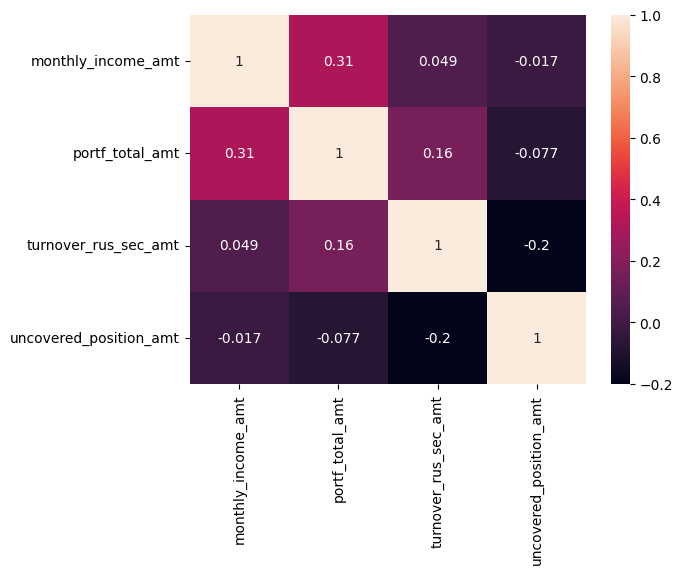

In [ ]:
numeric_cols = ['monthly_income_amt', 'portf_total_amt', 'turnover_rus_sec_amt', 'uncovered_position_amt']
sns.heatmap(df[numeric_cols].corr(method='spearman'), annot=True)

Сгруппируем инвесторов по уровню их дохода:

In [ ]:
bins = [0, 15000, 30000, 50000, np.inf]
labels = ['<15k', '15-30k', '30-50k', '50k+']
df['income_group'] = pd.cut(
    df['monthly_income_amt'],
    bins=bins,
    labels=labels,
    right=False
)

income_distribution = df['income_group'].value_counts(normalize=True) * 100
income_distribution

,proportion
income_group,
<15k,96.07197
15-30k,2.88900
30-50k,0.78561
50k+,0.25342


In [ ]:
metrics = df.groupby('income_group').agg({
    'portf_total_amt': ['median', 'mean'],
    'turnover_rus_sec_amt': 'sum',
    'margin_status_flg': lambda x: (x == 'Y').mean(),
    'uncovered_position_amt': lambda x: (x > 0).mean()
}).round(2)

metrics

/tmp/ipython-input-86-3032042587.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



portf_total_amt              turnover_rus_sec_amt  \
                      median         mean                  sum   
income_group                                                     
<15k              7109.00000  39572.89000      925427962.00000   
15-30k           51643.50000 168230.76000       46659610.00000   
30-50k           91491.50000 388996.36000      254665711.00000   
50k+            120962.00000 205611.50000        8468821.00000   

             margin_status_flg uncovered_position_amt  
                      <lambda>               <lambda>  
income_group                                           
<15k                   0.00000                0.00000  
15-30k                 0.00000                0.00000  
30-50k                 0.00000                0.00000  
50k+                   0.00000                0.02000

In [ ]:
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=metrics.index,
        y=metrics[('portf_total_amt', 'median')],
        marker_color='#FF69B4',
        text=metrics[('portf_total_amt', 'median')].apply(lambda x: f'{x:,.0f} руб.'),
        textposition='outside',
        textfont=dict(size=12, color='black')
    )
)

fig.update_layout(
    title='Медианный размер портфеля по доходным группам',
    xaxis_title='Доходная группа',
    yaxis_title='Размер портфеля, руб.',
    plot_bgcolor='white',
    showlegend=False,
    yaxis=dict(
        gridcolor='lightgray',
        zerolinecolor='lightgray'
    ),
)

fig.update_traces(
    marker_line_color='#C71585',
    marker_line_width=1.5,
    opacity=0.8
)

fig.show()

##Корреляция основных признаков (демографических, финансовой активности и т.п.)

Будем проверять корреляцию между следующими признаками:

In [ ]:
cols_for_corr = [
    'age', 'monthly_income_amt', 'children_cnt', 'education_rank',
    'turnover_rus_sec_amt', 'turnover_rus_bon_amt', 'turnover_etf_amt',
    'trade_order_rus_sec_cnt', 'trade_order_rus_bon_cnt',
    'uncovered_position_amt', 'initial_margin_amt', 'margin_status_flg',
    'in_payment_rub_amt', 'out_payment_rub_amt', 'portf_total_amt'
]

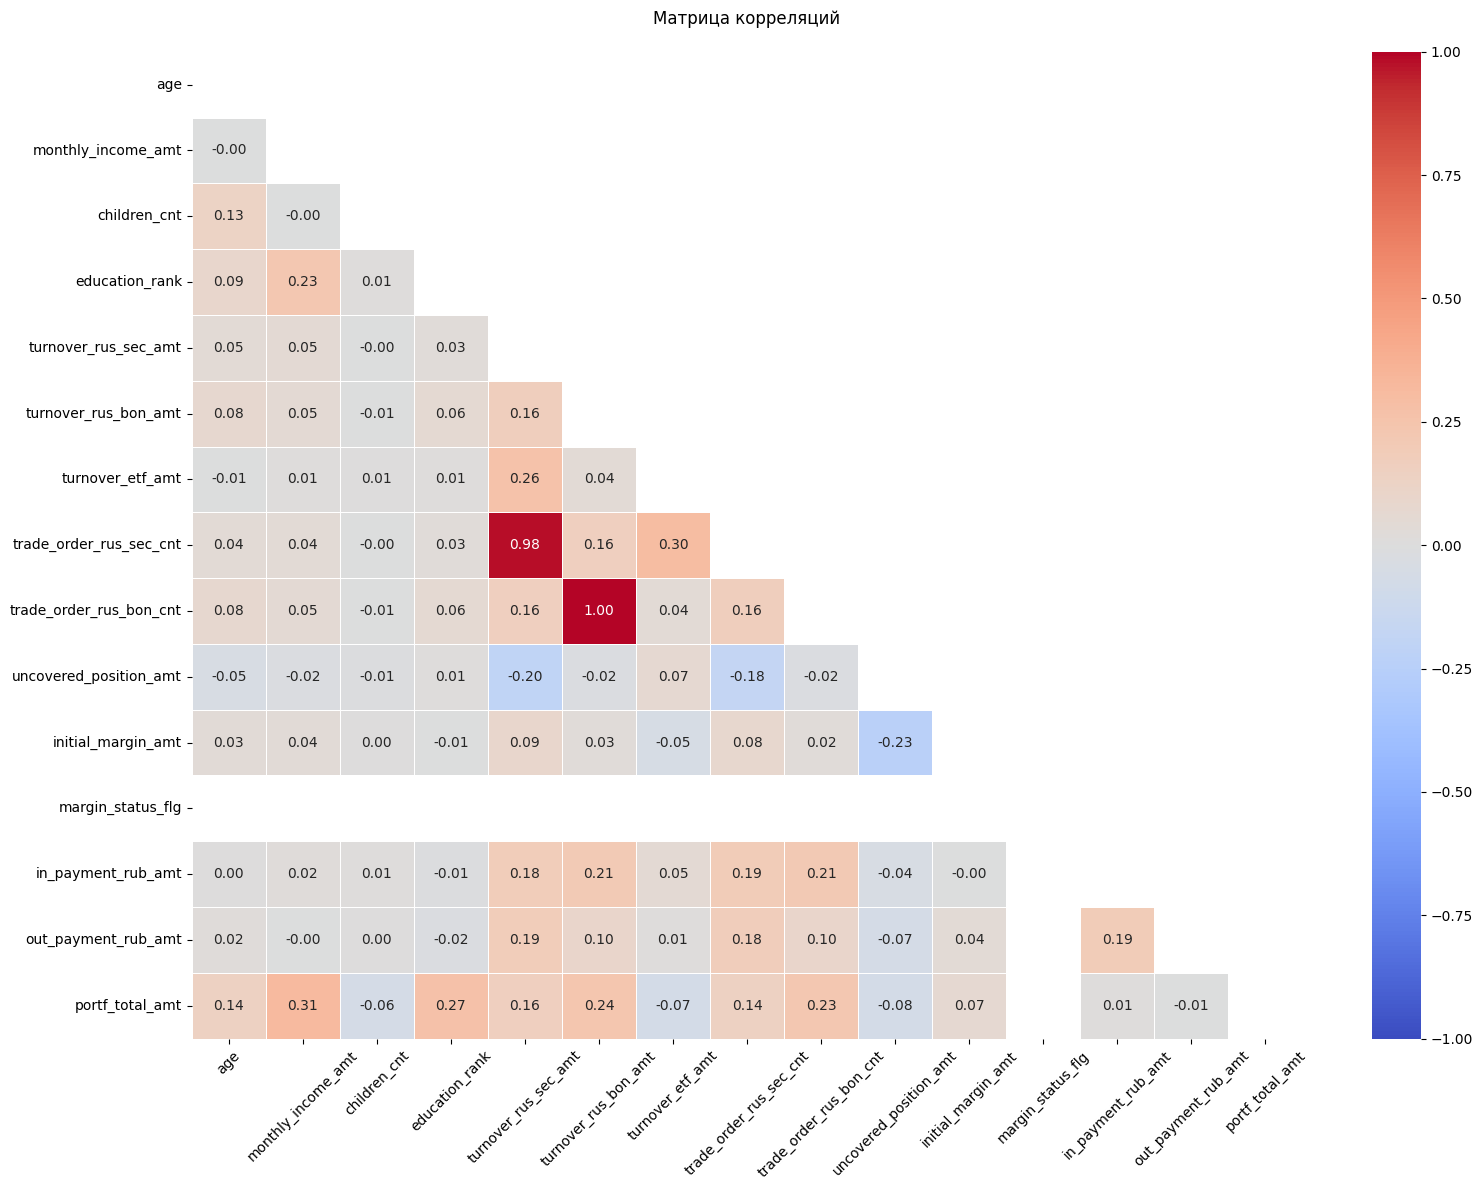

In [ ]:
df_numeric = df.copy()
df_numeric['margin_status_flg'] = df_numeric['margin_status_flg'].map({'Y': 1, 'N': 0})
corr_matrix = df_numeric[cols_for_corr].corr(method='spearman')

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    mask=np.triu(np.ones_like(corr_matrix)) )
plt.title("Матрица корреляций", pad=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Доля на рынке

Количество частных инвесторов, имеющих брокерские счета на Московской бирже, за 2024 год увеличилось на 5,4 млн и достигло 35,1 млн. Оборот за 2024 год вырос на 400 млрд рублей. [Источник - https://www.moex.com/n76900 ]

Так как мне предоставлена база данных клиентов и их характеристики за 3 месяца использования доступных инструментов Т-Инвестиций, усредним прирост инвесторов и счетов на Московской бирже, получим:

Количество частных инвесторов за 3 месяца увеличилось на 1,35 млн, оборот за этот период вырос на 100 млрд руб

In [ ]:
total_clients_tbank = df['id'].nunique()
total_turnover_tbank = (
    df['turnover_rus_sec_amt'].sum() +
    df['turnover_rus_bon_amt'].sum() +
    df['turnover_etf_amt'].sum() +
    df['turnover_forts_amt'].sum() +
    df['turnover_opt_amt'].sum() +
    df['turnover_ore_prc_amt'].sum() +
    df['turnover_ore_sel_amt'].sum()
)
total_clients_tbank, total_turnover_tbank

(5093, np.float64(2493913032.0))

In [ ]:
tbank_metrics = {
    'clients': total_clients_tbank,
    'turnover': total_turnover_tbank
}

market_metrics = {
    'clients': 1_350_000,
    'turnover': 100_000_000_000
}

shares = {
    metric: (tbank_metrics[metric] / market_metrics[metric]) * 100
    for metric in tbank_metrics
}

pd.DataFrame.from_dict(shares, orient='index', columns=['Доля рынка(%)'])

,Доля рынка(%)
clients,0.37726
turnover,2.49391
